In [ ]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from generalized_contrastive_PCA import gcPCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

In [2]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

In [3]:
data_dir = 'C:/user-link/Documents/data/preprocessed_data/'
out_path = 'C:/user-link/Documents/data/derivatives/'
scores_path = 'C:/user-link/Documents/data/LOR_scores'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


In [4]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [5]:
burst_times = all_bursts['waveform_times'] * 1000 

In [6]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

In [7]:
on_idx = (all_bursts['med']=='ON')
off_idx = (all_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [85]:
def reject_outliers(X, m=3):
    """
    https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')
    mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    return [d for d in X if lower_bound <= d <= upper_bound]

In [80]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad, method='standard'):
    if np.any(mad == 0):
        raise ValueError("MAD is zero for at least one feature, cannot scale data.")

    if method == 'robust':
        return 0.67449 * np.abs(X - median) / mad
    elif method == 'standard':
        return (X - median) / mad

 bins: [-1.76410875e-04 -1.25695705e-05 -3.74414266e-07  1.18061360e-05
  1.01015503e-04]
  subject: s02, gcPC0, q=0, n_bursts=474
 bins: [-1.30995144e-04 -8.51882674e-06  6.84145958e-06  2.47599255e-05
  1.79565048e-04]
  subject: s02, gcPC1, q=0, n_bursts=474
 bins: [-1.37904192e-04 -3.36826885e-05 -1.56631448e-06  2.67181018e-05
  1.22897719e-04]
  subject: s02, gcPC-2, q=0, n_bursts=474
 bins: [-8.49577651e-05 -2.35431689e-05 -1.29373473e-06  2.43108504e-05
  1.06038957e-04]
  subject: s02, gcPC-1, q=0, n_bursts=474
 bins: [-1.76410875e-04 -1.25695705e-05 -3.74414266e-07  1.18061360e-05
  1.01015503e-04]
  subject: s02, gcPC0, q=1, n_bursts=474
 bins: [-1.30995144e-04 -8.51882674e-06  6.84145958e-06  2.47599255e-05
  1.79565048e-04]
  subject: s02, gcPC1, q=1, n_bursts=474
 bins: [-1.37904192e-04 -3.36826885e-05 -1.56631448e-06  2.67181018e-05
  1.22897719e-04]
  subject: s02, gcPC-2, q=1, n_bursts=474
 bins: [-8.49577651e-05 -2.35431689e-05 -1.29373473e-06  2.43108504e-05
  1.0603

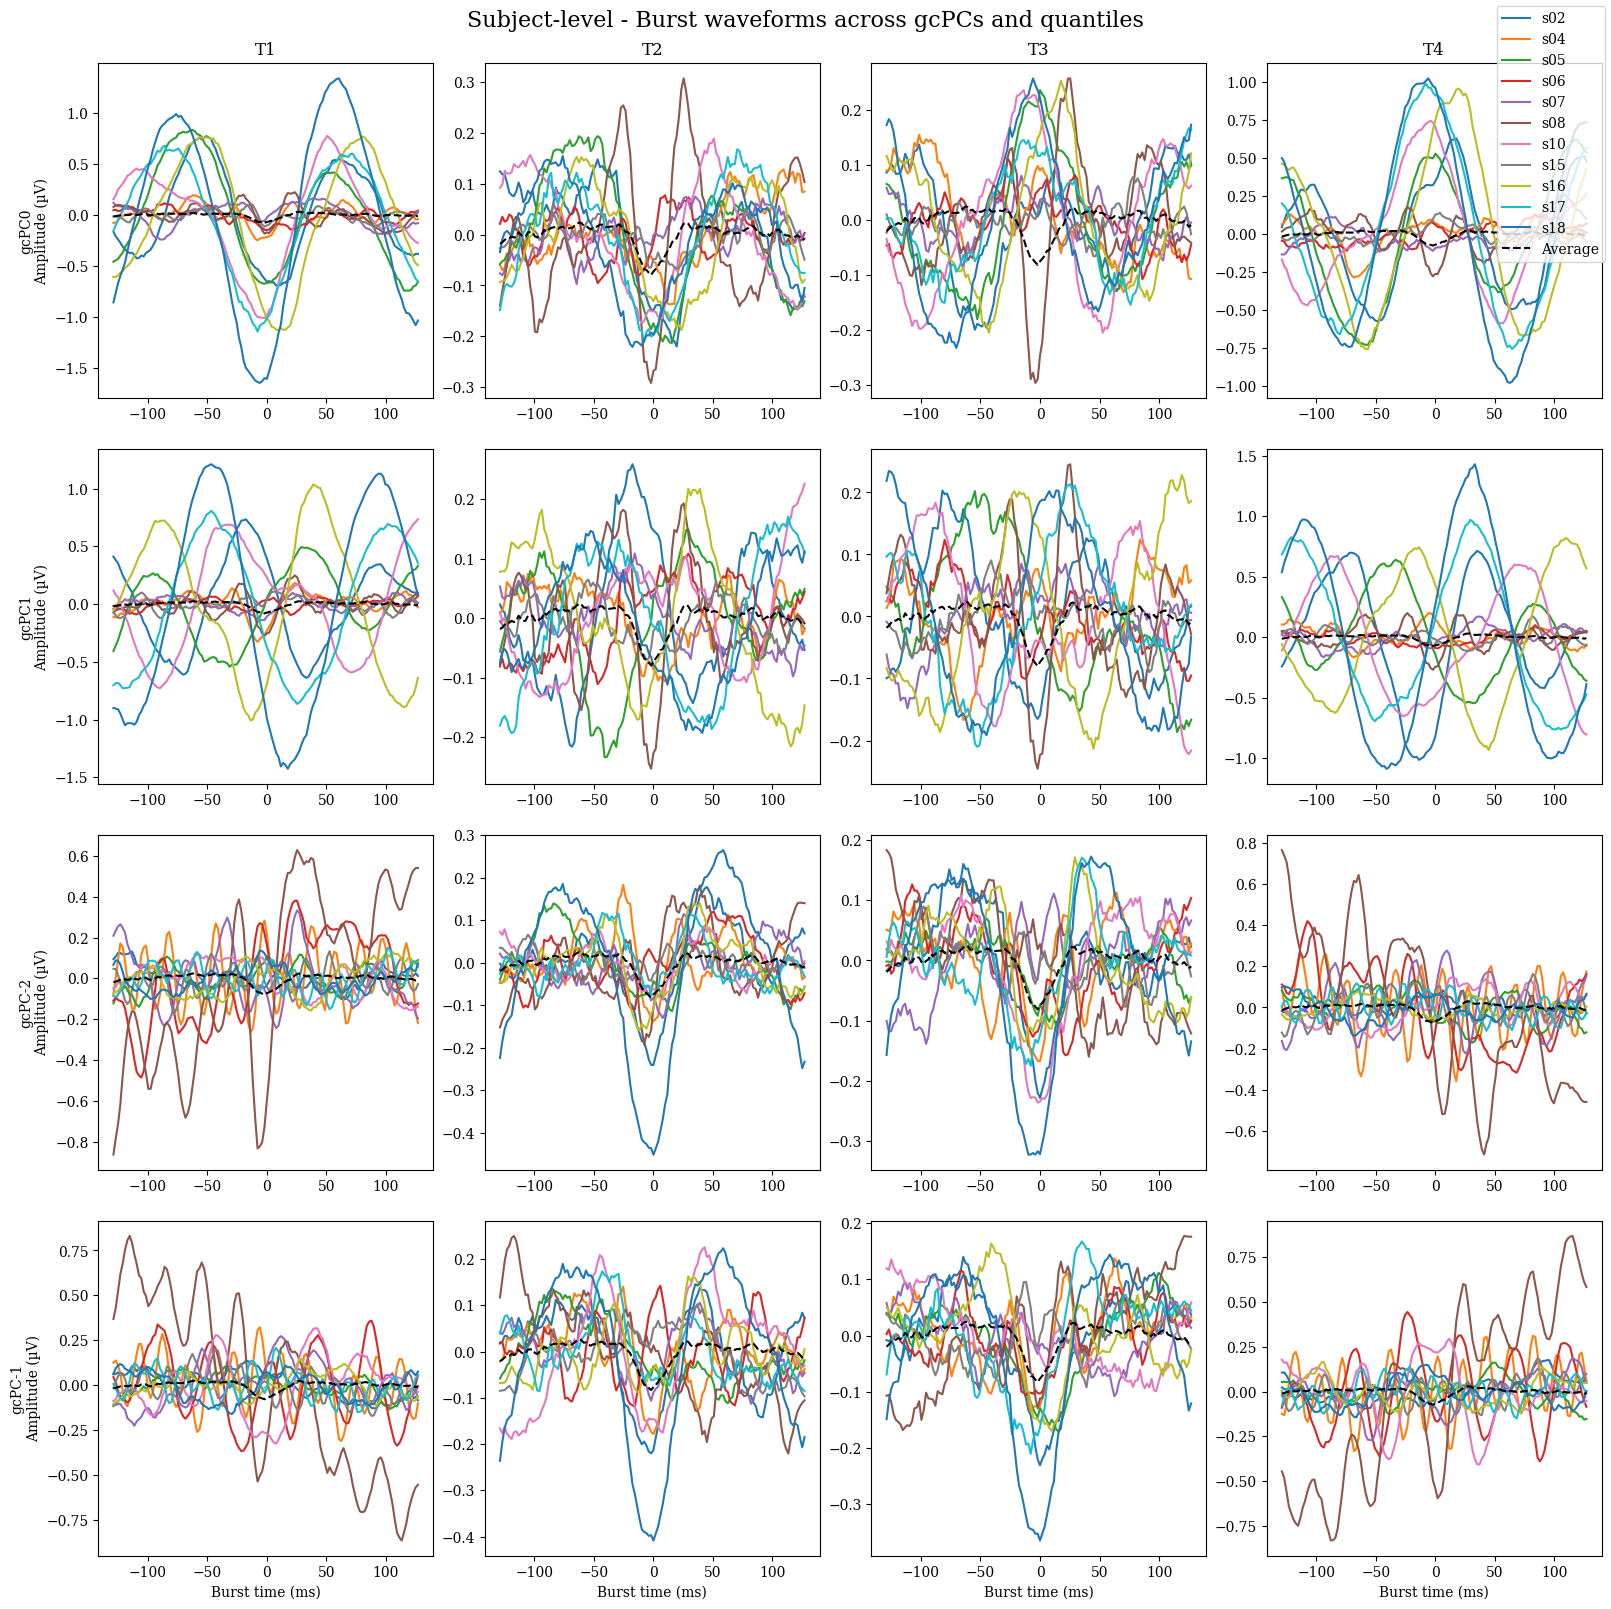

In [92]:
where = stn_idx

# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

n_q = 4
col_r = plt.cm.cool(np.linspace(0, 1, num=n_q))
rev_col_r = col_r[::-1]
step = 100 / n_q

gcPC = [0, 1, -2, -1]

# fig, ax = plt.subplots(1, n_q, figsize=(3*n_q, len(gcPC)), constrained_layout=True)
fig, ax = plt.subplots(len(gcPC), n_q, figsize=(4*n_q, len(gcPC)*4), constrained_layout=True)

labels = []
q_waveforms = []
subjects_scores = []
for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    subj_outlier_free_idx = subj_idx & where & np.isin(all_bursts['peak_amp_base'], reject_outliers(all_bursts['peak_amp_base'][subj_idx & where]))
    # scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the median and IQR values
    # scaler = StandardScaler().fit(all_bursts['waveform'][subj_idx & where])               # .fit() returns the mean and std values
    median, mad = scaler_fit(all_bursts['waveform'][subj_outlier_free_idx & where])               # .fit() returns the median and IQR values
    subj_outlier_free_med = all_bursts['med'][subj_outlier_free_idx & where]
    subj_outlier_free_bursts = all_bursts['waveform'][subj_outlier_free_idx & where,:]
    subj_on_idx = (subj_outlier_free_med=='ON')
    subj_off_idx = (subj_outlier_free_med=='OFF')
    # subj_scaled_waveforms = scaler.transform(subj_bursts)
    subj_scaled_waveforms = scaler_transform(subj_outlier_free_bursts, median, mad)

    sub_gcpca_model = gcPCA(method='v4', normalize_flag=False)
    # sub_gcpca_model.fit(subj_bursts[subj_on_idx[train_s_idx],:], subj_bursts[subj_off_idx[train_s_idx],:])
    # sub_gcpca_model.fit(subj_scaled_waveforms[train_bursts_on_idx,:], subj_scaled_waveforms[train_bursts_off_idx,:])
    sub_gcpca_model.fit(subj_scaled_waveforms[subj_on_idx,:], subj_scaled_waveforms[subj_off_idx,:])
    subj_scores = subj_scaled_waveforms @ sub_gcpca_model.loadings_
    subjects_scores.append(subj_scores)

    for q in range(n_q):
        for col in gcPC:
            q_bins = np.percentile(subj_scores[:, col], np.arange(0, 100+step, step))
            print(" bins:", q_bins)

            if q==(n_q-1):
                lims = (subj_scores[:, col] >= q_bins[q])
            else:
                lims = (subj_scores[:, col] >= q_bins[q]) & (subj_scores[:, col] < q_bins[q+1])
            print(f'  subject: {subject}, gcPC{col}, q={q}, n_bursts={len(np.where(lims)[0])}')
            q_waveform = np.mean(subj_scaled_waveforms[lims, :], axis=0)
            q_waveforms.append(q_waveform)

            if len(np.where(lims)[0]) > 0:
                label = f'{subject}'
            else:
                label = None

            if label not in labels:
                labels.append(label)

            ax[col, q].plot(burst_times, q_waveform, label=label)
            ax[len(gcPC)-1, q].set_xlabel('Burst time (ms)')
            ax[col, 0].set_ylabel(f'gcPC{col}\nAmplitude (µV)')
            ax[0, q].set_title(f"T{q+1}")
            ax[col, q].set_box_aspect(1)

            if subject == np.unique(all_bursts['subject'])[-1]:
                print(subject)
                ax[col, q].plot(burst_times, np.mean(q_waveforms, axis=0), color='black', linestyle='--', label='Average')

                if 'Average' not in labels:
                    labels.append('Average')

fig.suptitle('Subject-level - Burst waveforms across gcPCs and quantiles', fontsize=16)
fig.legend(labels=labels)

Text(0.5, 0.98, 'Subject-level - Peak amplitude distributions in STN')

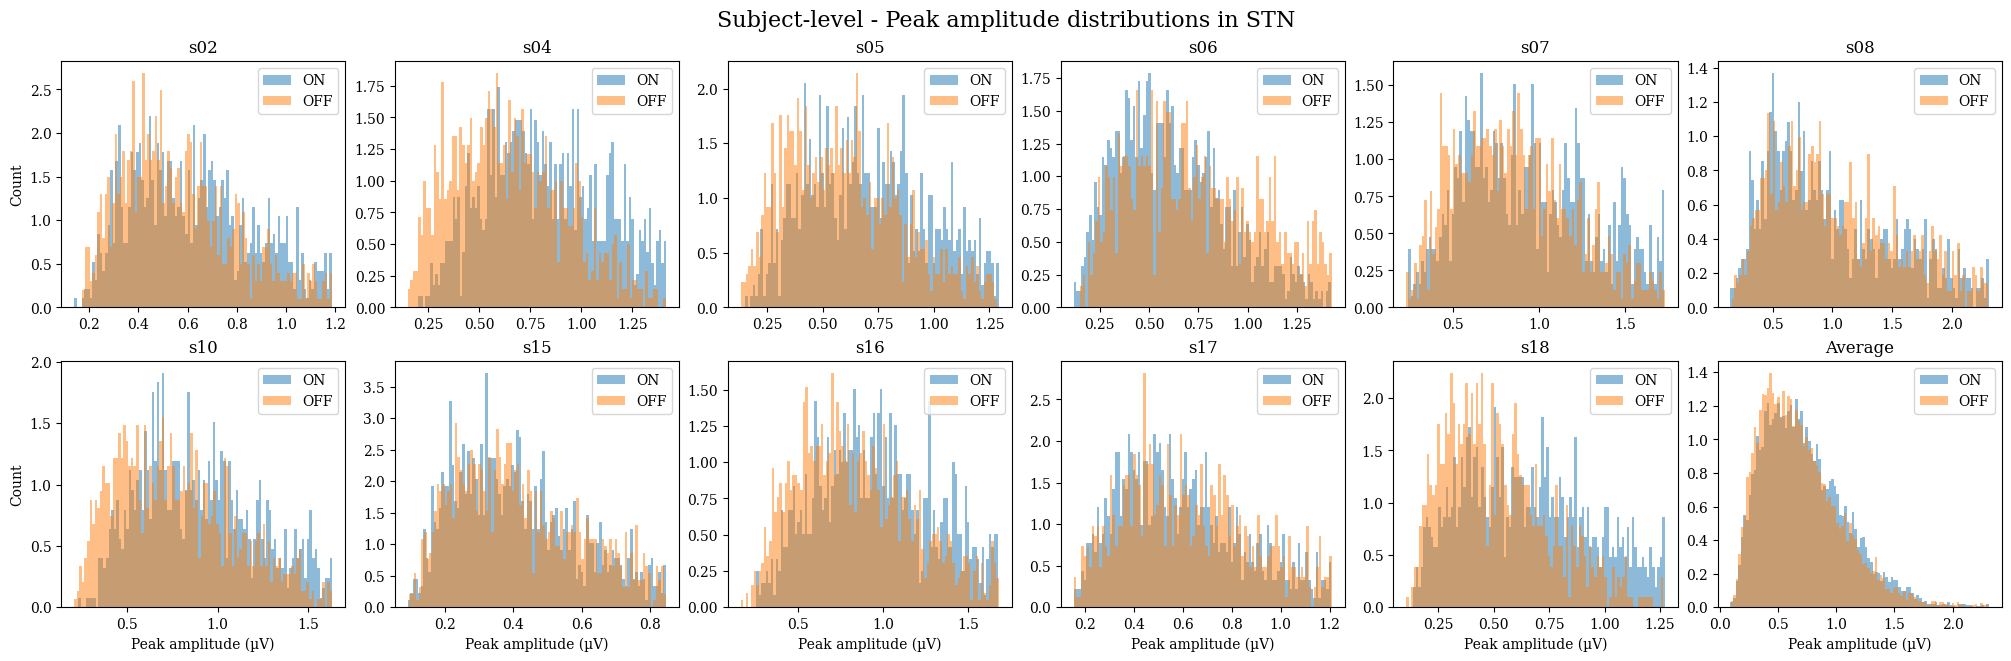

In [99]:
where = stn_idx

n_bins = 100

subjects = np.unique(all_bursts['subject'])
sub_by_2 = len(subjects) // 2

fig, ax = plt.subplots(2, sub_by_2+1, figsize=(4*sub_by_2, 1.3*sub_by_2), constrained_layout=True)
ax = ax.flatten()

peaks_amps_on = []
peaks_amps_off = []
for i, subject in enumerate(subjects):
    subj_idx = (all_bursts['subject'] == subject)
    subj_outlier_free_idx = subj_idx & where & np.isin(all_bursts['peak_amp_base'], reject_outliers(all_bursts['peak_amp_base'][subj_idx & where]))

    median, mad = scaler_fit(all_bursts['waveform'][subj_outlier_free_idx & where])
    subj_med = all_bursts['med'][subj_outlier_free_idx & where]
    subj_bursts = all_bursts['waveform'][subj_outlier_free_idx & where,:]
    subj_on_idx = (subj_med=='ON')
    subj_off_idx = (subj_med=='OFF')
    subj_scaled_waveforms = scaler_transform(subj_bursts, median, mad, method='standard')
    subj_peak_amps = all_bursts['peak_amp_base'][subj_outlier_free_idx & where]
    subj_peak_amps_on = subj_peak_amps[subj_on_idx]
    subj_peak_amps_off = subj_peak_amps[subj_off_idx]

    peaks_amps_on.append(subj_peak_amps_on)
    peaks_amps_off.append(subj_peak_amps_off)

    ax[i].hist(subj_peak_amps_on, label='ON', alpha=0.5, density=True, bins=n_bins)
    ax[i].hist(subj_peak_amps_off, label='OFF', alpha=0.5, density=True, bins=n_bins)
    ax[i].set_title(f'{subject}')
    ax[i].legend()

    if subject == subjects[-1]:
        ax[i+1].hist(np.hstack(peaks_amps_on), label='ON', alpha=0.5, density=True, bins=n_bins)
        ax[i+1].hist(np.hstack(peaks_amps_off), label='OFF', alpha=0.5, density=True, bins=n_bins)
        ax[i+1].set_title('Average')
        ax[i+1].set_xlabel('Peak amplitude (µV)')
        ax[i+1].legend()   

    if i == 0 or i == sub_by_2+1:
        ax[i].set_ylabel('Count') 

    if i >= sub_by_2+1:
        ax[i].set_xlabel('Peak amplitude (µV)')

fig.suptitle('Subject-level - Peak amplitude distributions in STN', fontsize=16)
